# JointView
JointView can be used to visualize trans or cis-remote region by composing frames around a hicmat.

In [1]:
import coolbox
from coolbox.api import *

In [2]:
coolbox.__version__

'0.4.0'

Visualize the cis-remote region:

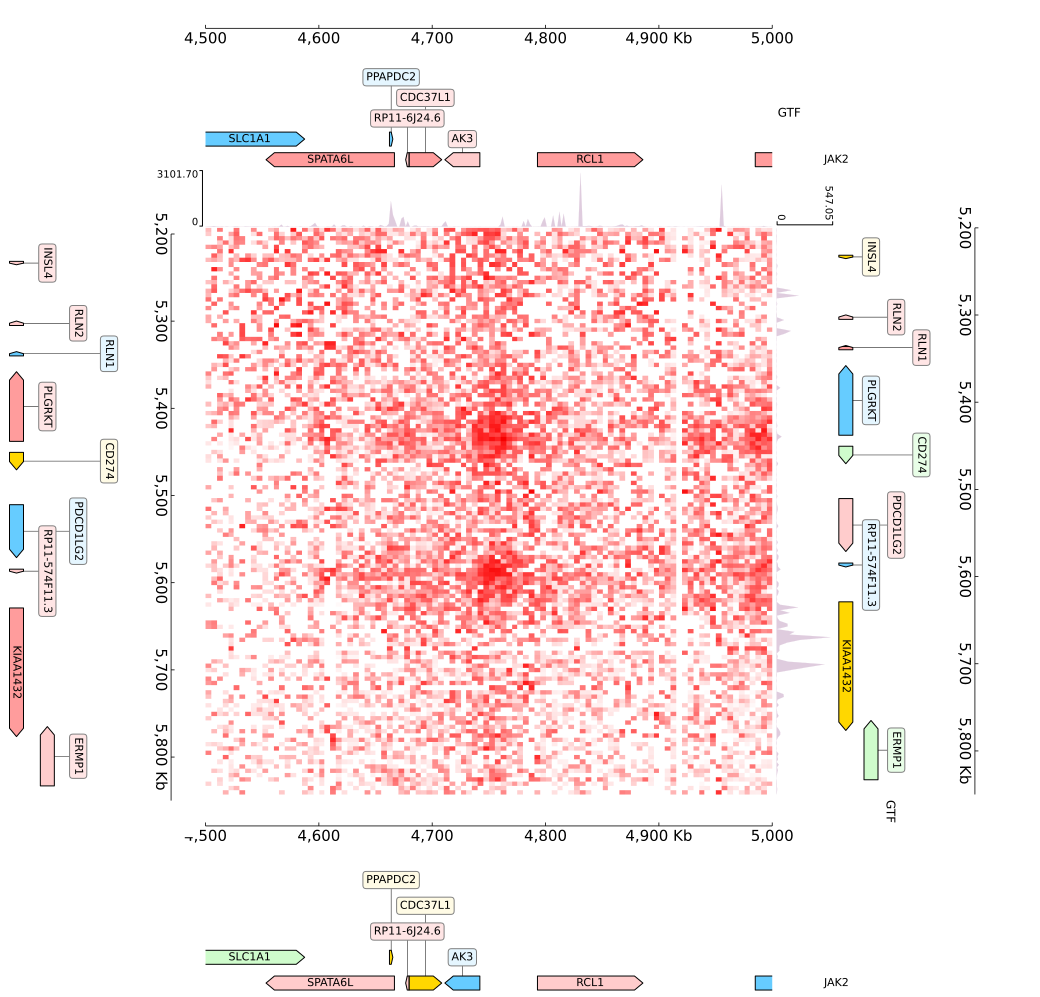

In [3]:
DATA_DIR = f"../../../tests/test_data"
test_interval = "chr9:4000000-6000000"
empty_interval = "chr10:4000000-6000000"
test_itv = test_interval.replace(':', '_').replace('-', '_')


frame1 = XAxis() + GTF(f"{DATA_DIR}/gtf_{test_itv}.gtf") + Title("GTF")
frame1 += BigWig(f"{DATA_DIR}/bigwig_{test_itv}.bw") + TrackHeight(2) + MinValue(0)
frame2 = XAxis()
frame2 += GTF(f"{DATA_DIR}/gtf_{test_itv}.gtf") + TrackHeight(5)

cool1 = Cool(f"{DATA_DIR}/cool_{test_itv}.mcool", color_bar=False, style='matrix')

sub_frames = {
    "top": frame1,
    "right": frame1,
    "bottom": frame2,
    "left": frame2
}

jv = JointView(cool1, **sub_frames, space=0, padding_left=0)
fig = jv.plot("chr9:4500000-5000000", "chr9:5200000-5850000")
fig

Or you can just use it to compose track in joint style,
pass one genome region to the `plot` method:

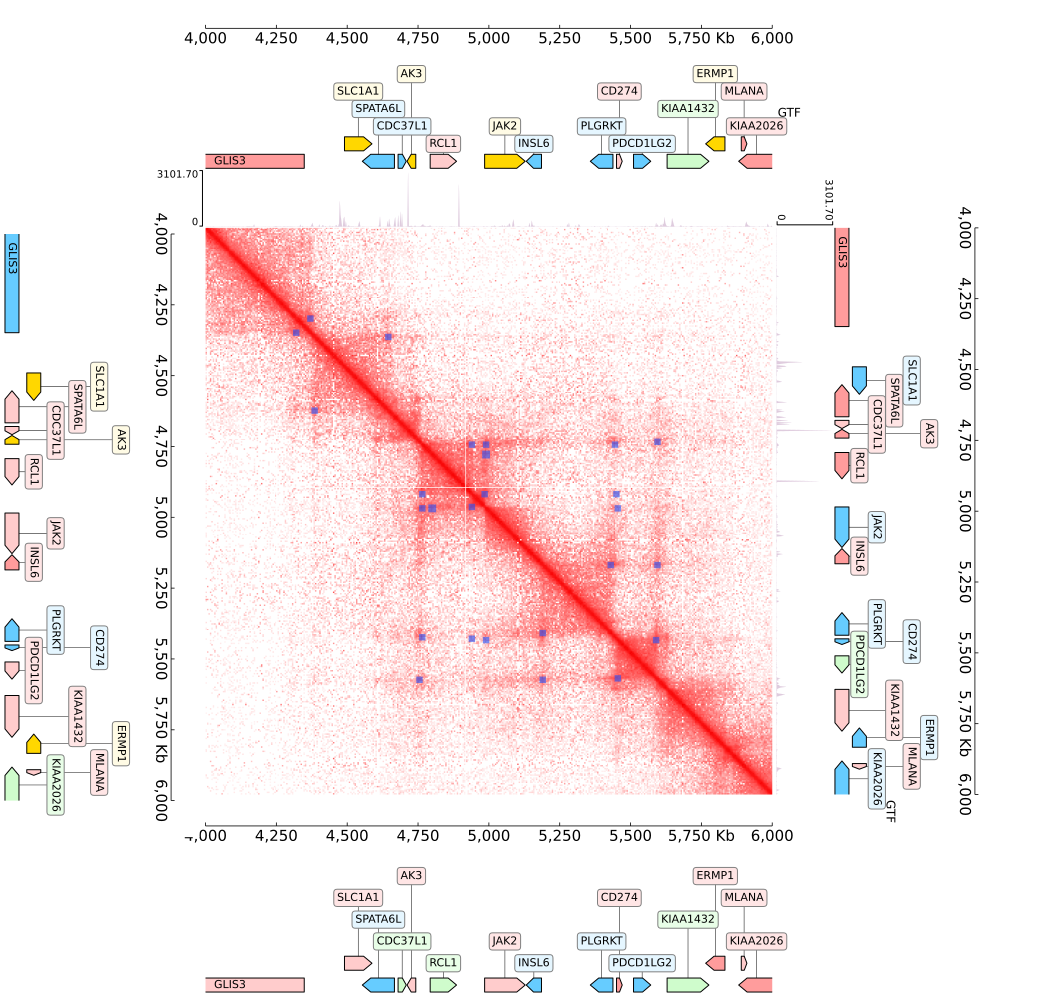

In [4]:
cool1 = Cool(f"{DATA_DIR}/cool_{test_itv}.mcool", color_bar=False) + \
        HiCPeaksCoverage(f"{DATA_DIR}/peak_{test_itv}.bedpe")

sub_frames = {
    "top": frame1,
    "right": frame1,
    "bottom": frame2,
    "left": frame2
}

jv = JointView(cool1, **sub_frames, space=0, padding_left=0)
fig = jv.plot("chr9:4000000-6000000")
fig

### CLI code

In [5]:
%%bash

DATA_DIR="../../../tests/test_data"
test_itv="chr9_4000000_6000000"
coolbox \
  joint_view top - \
    add XAxis - \
    add GTF ${DATA_DIR}/gtf_${test_itv}.gtf - \
    add Title GTF - \
  joint_view right - \
    add XAxis - \
    add BigWig ${DATA_DIR}/bigwig_${test_itv}.bw - \
    add TrackHeight 2 - \
    add MinValue 0 - \
  joint_view center - \
    add Cool ${DATA_DIR}/cool_${test_itv}.mcool  - \
  goto 'chr9:4500000-5000000' 'chr9:5200000-5850000' - \
  plot /tmp/test_coolbox_joint_view.svg